# 2110446 DATA SCIENCE AND DATA ENGINEERING

## **Midterm:** Traffy Fondue

- **Author:** Worralop Srichainont
- **Year:** 2025 (Semester 2)

## **Notebook II:** Exploratory Data Analysis (EDA)

In this notebook, we are focus on analyze the clean dataset to find insight of the data.

# **Part 0:** Dependencies

In [1]:
!pip -q install pythainlp python-crfsuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.4 MB/s eta 0:00:00


In [2]:
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from transformers import AutoTokenizer
from pythainlp.tokenize import word_tokenize
from pythainlp.corpus import thai_stopwords
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

Setup Thai font for `matplotlib`

In [3]:
FONT_NAME = "Sarabun"
FONT_FILENAME = "Sarabun.ttf"
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"


In [4]:
urllib.request.urlretrieve(FONT_URL, FONT_FILENAME)
mpl.font_manager.fontManager.addfont(FONT_FILENAME)
mpl.rc("font", family=FONT_NAME)

# **Part 1:** Load Dataset

In [5]:
TRAIN_FILE_PATH = (
    "/kaggle/input/datasets/worralopsrichainont/2110446-dsde-midterm-dataset-cleaned/train_cleaned.csv"
)

TEST_FILE_PATH = (
    "/kaggle/input/datasets/worralopsrichainont/2110446-dsde-midterm-dataset-cleaned/test_cleaned.csv"
)

In [6]:
df_train = pd.read_csv(TRAIN_FILE_PATH)
df_test = pd.read_csv(TEST_FILE_PATH)

Get brief details of the dataset

In [7]:
print(f"The train dataset has {df_train.shape[0]} rows and {df_train.shape[1]} columns")
for col_name in df_train.columns:
    print(f"- {col_name}")

The train dataset has 304284 rows and 14 columns
- id
- comment
- สำนักงานตำรวจแห่งชาติ
- การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย
- สภาเด็กและเยาวชนกรุงเทพมหานคร
- กรมควบคุมมลพิษ
- กรมสรรพสามิต
- การไฟฟ้านครหลวง
- กรมทางหลวง
- สำนักงานประกันสุขภาพแห่งชาติ
- การประปานครหลวง
- คณะกรรมการการพัฒนาเศรษฐกิจ
- กระทรวงการท่องเที่ยวและกีฬา
- สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200


In [8]:
print(f"The test dataset has {df_test.shape[0]} rows and {df_test.shape[1]} columns")
for col_name in df_test.columns:
    print(f"- {col_name}")

The test dataset has 37406 rows and 2 columns
- id
- comment


Display `DataFrame`

In [9]:
df_train.head()

,id,comment,สำนักงานตำรวจแห่งชาติ,การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย,สภาเด็กและเยาวชนกรุงเทพมหานคร,กรมควบคุมมลพิษ,กรมสรรพสามิต,การไฟฟ้านครหลวง,กรมทางหลวง,สำนักงานประกันสุขภาพแห่งชาติ,การประปานครหลวง,คณะกรรมการการพัฒนาเศรษฐกิจ,กระทรวงการท่องเที่ยวและกีฬา,สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200
0,0,ทำไมปล่อยให้จุดพลุกันสนั่นหวั่นไหว,0,0,0,0,0,0,0,0,0,0,0,0
1,1,แจ้งว่าการจุดพลุต้องขออนุญาต ทำไมจุดกันมากมายข...,0,0,0,0,0,0,0,0,0,0,0,0
2,2,คาดว่ามีการจุดพลุไม่ขอทางกรุงเทพให้ถูกต้อง ส่ง...,0,0,0,0,0,0,0,0,0,0,0,0
3,3,ไม่แน่ใจ กทม อนุญาตให้ร้านชอคโกแลตวิลจุพลุถึงก...,0,0,0,0,0,0,0,0,0,0,0,0
4,4,ไม่ทราบใครจัดงานปีใหม่ละแวกนี้ เปิดเสียงเพลงดั...,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
df_test.head()

,id,comment
0,0,รถติดจังเลยครับ อยากได้เกาะกลาง ที่ขยับเพิ่มเล...
1,1,ในซอยมีการเตรียมทำท่อระบายน้ำ โดยผู้รับเหมา มา...
2,2,มีต้นไม้กีดขวางทางสัญจรไปมาทำให้เกิดอันตราย
3,3,ร้านนวดบริเวณนี้วางของเกะกะบนทางเท้ามากมาย
4,4,ศูนย์เรื่องราวร้องทุกข์ ได้รับการประสานผ่านระบ...


# **Part 2:** Class Count

## 2.1. Configuration

In [11]:
CATEGORY_MAP = {
    "สำนักงานตำรวจแห่งชาติ": "ตำรวจ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย": "รถไฟฟ้า",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร": "สภาเด็ก",
    "กรมควบคุมมลพิษ": "มลพิษ",
    "กรมสรรพสามิต": "สรรพสามิต",
    "การไฟฟ้านครหลวง": "ไฟฟ้า",
    "กรมทางหลวง": "ทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ": "ประกันสุขภาพ",
    "การประปานครหลวง": "ประปา",
    "คณะกรรมการการพัฒนาเศรษฐกิจ": "เศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา": "ท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200": "กสทช",
}

TARGET_COLS = list(CATEGORY_MAP.keys())

## 2.2. Plotting Function

In [12]:
class ClassCountUtility:
    @staticmethod
    def get_value_counts_df(df):
        # Rename columns using map
        label_df = df[TARGET_COLS].rename(columns=CATEGORY_MAP)

        # Counting and sorting in descending order
        class_counts = label_df.sum().sort_values(ascending=False)

        # Create a new DataFrame
        class_df = class_counts.reset_index()
        class_df.columns = ["organization", "count"]

        # Return the new DataFrame
        return class_df

In [13]:
class ClassCountPlot:
    @staticmethod
    def get_table(df):
        # Get total amount of rows
        n_rows = df.shape[0]

        # Count each class in the DataFrame
        class_df = ClassCountUtility.get_value_counts_df(df)

        # Calculate percentage
        class_df["percentage"] = (class_df["count"] / n_rows) * 100.00
        return class_df

    @staticmethod
    def get_plot(df, plot_title):
        # Count each class in the DataFrame
        class_df = ClassCountUtility.get_value_counts_df(df)

        # Create a plot figure
        plt.figure(figsize=(14, 6))
        plt.title(plot_title, fontsize=18)

        # Create a barplot
        ax = sns.barplot(
            data=class_df,
            x="organization",
            y="count",
            hue="organization",
            errorbar=None,
            palette="viridis",
        )

        # Set to logarithmic scale
        ax.set_yscale("log")

        # Add label to the bars
        for bar in ax.containers:
            ax.bar_label(bar)

        # Display the plot
        plt.show()

## 2.3. Class Count Bar Chart

In [14]:
ClassCountPlot.get_table(df_train)

,organization,count,percentage
0,ตำรวจ,35078,11.528046
1,ไฟฟ้า,20032,6.583323
2,ทางหลวง,7685,2.525601
3,กสทช,4590,1.508459
4,ประปา,3029,0.995452
5,รถไฟฟ้า,2613,0.858737
6,มลพิษ,1976,0.649393
7,ประกันสุขภาพ,75,0.024648
8,สรรพสามิต,46,0.015117
9,ท่องเที่ยวและกีฬา,42,0.013803


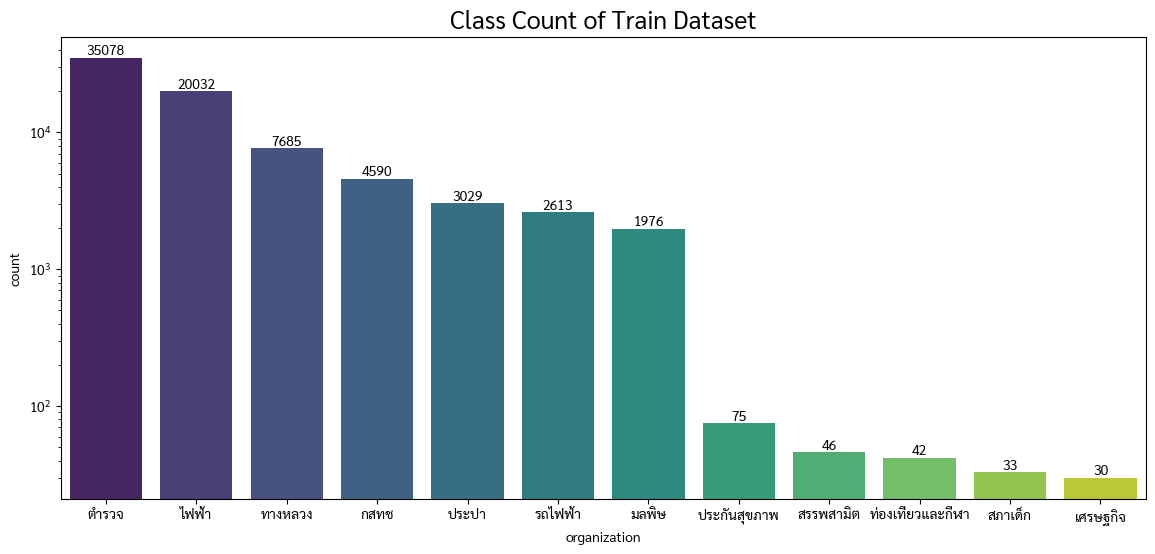

In [15]:
ClassCountPlot.get_plot(df_train, "Class Count of Train Dataset")

## 2.4. Insight

The train dataset is clearly imbalance.

As we can see, the majority of report cases are belongs to these organizations:
- สำนักงานตำรวจแห่งชาติ (11.528%)
- การไฟฟ้านครหลวง (6.583%)
- กรมทางหลวง (2.526%)

While these organizations rarely got any report.
- สำนักงานประกันสุขภาพแห่งชาติ (0.025%)
- สรรพสามิต (0.015%)
- ท่องเที่ยวและกีฬา (0.014%)
- สภาเด็ก (0.011%)
- เศรษฐกิจ (0.010%)

Since this midterm exam are using macro F1 score as evaluation metrics in Kaggle competition, we are not dropping these columns but adjusting weight on loss function instead.

# **Part 3:** Label Cardinality

## 3.1. Configuration

In [16]:
CATEGORY_MAP = {
    "สำนักงานตำรวจแห่งชาติ": "ตำรวจ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย": "รถไฟฟ้า",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร": "สภาเด็ก",
    "กรมควบคุมมลพิษ": "มลพิษ",
    "กรมสรรพสามิต": "สรรพสามิต",
    "การไฟฟ้านครหลวง": "ไฟฟ้า",
    "กรมทางหลวง": "ทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ": "ประกันสุขภาพ",
    "การประปานครหลวง": "ประปา",
    "คณะกรรมการการพัฒนาเศรษฐกิจ": "เศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา": "ท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200": "กสทช",
}

TARGET_COLS = list(CATEGORY_MAP.keys())
SHORT_TARGET_COLS = list(CATEGORY_MAP.values())

## 3.2. Plotting Function

In [17]:
class LabelCardinalityUtility:
    @staticmethod
    def get_cardinality_dist(df):
        # Count amount of label in each rows
        label_counts = df[TARGET_COLS].sum(axis=1)

        # Count amount of rows with each label count
        cardinality_dist = label_counts.value_counts().sort_index()

        # Create a new DataFrame
        cardinality_dist = cardinality_dist.reset_index()
        cardinality_dist.columns = ["label_cardinality", "counts"]

        return cardinality_dist

    @staticmethod
    def get_category_cardinality_dist(df):
        # Rename columns using map
        df_labels = df[TARGET_COLS].rename(columns=CATEGORY_MAP)

        # Create a new columns with label counts in each rows
        df_labels["total_labels"] = df_labels.sum(axis=1)

        # Create a dict to store label cardinality of each class
        cardinality_dict = {}
        for col_name in SHORT_TARGET_COLS:
            # Filter only rows where this organization is tagged
            organization_subset = df_labels[df_labels[col_name] == 1]

            # Calculate label cardinality for this organization
            organization_cardinality = organization_subset[
                "total_labels"
            ].value_counts()
            cardinality_dict[col_name] = organization_cardinality

        # Convert the dictionary to a DataFrame, then transpose
        df_cardinality = pd.DataFrame(cardinality_dict).T

        # Sort columns by cardinality
        df_cardinality = df_cardinality.reindex(sorted(df_cardinality.columns), axis=1)

        # Sort DataFrame by 1 label counts
        df_cardinality = df_cardinality.sort_values(by=1, ascending=False)

        return df_cardinality

In [18]:
class LabelCardinalityPlot:
    @staticmethod
    def get_overall_plot(df, plot_title):
        # Calculate label cardinality distribution
        cardinality_dist = LabelCardinalityUtility.get_cardinality_dist(df)

        # Create a plot figure
        plt.figure(figsize=(12, 8))
        plt.title(plot_title, fontsize=18)

        # Create a barplot
        ax = sns.barplot(
            data=cardinality_dist,
            x="label_cardinality",
            y="counts",
            hue="label_cardinality",
            errorbar=None,
            palette="viridis",
        )

        # Set to logarithmic scale
        ax.set_yscale("log")

        # Add label to the bars
        for bar in ax.containers:
            ax.bar_label(bar)

        # Display the plot
        plt.show()

    @staticmethod
    def get_category_plot(df, plot_title):
        # Calculate label cardinality distribution separated by category
        cardinality_dist = LabelCardinalityUtility.get_category_cardinality_dist(df)

        # Create a stacked barplot
        ax = cardinality_dist.plot(
            kind="barh", stacked=False, cmap="viridis", figsize=(12, 16), width=0.85
        )

        # Set title of the figure
        plt.title(plot_title, fontsize=18)

        # Set to logarithmic scale
        ax.set_xscale("log")

        # Add label to the bars
        for bar in ax.containers:
            ax.bar_label(bar)

        # Invert the y-axis
        ax.invert_yaxis()

        # Display the plot
        plt.show()

## 3.3. Overall Label Cardinality

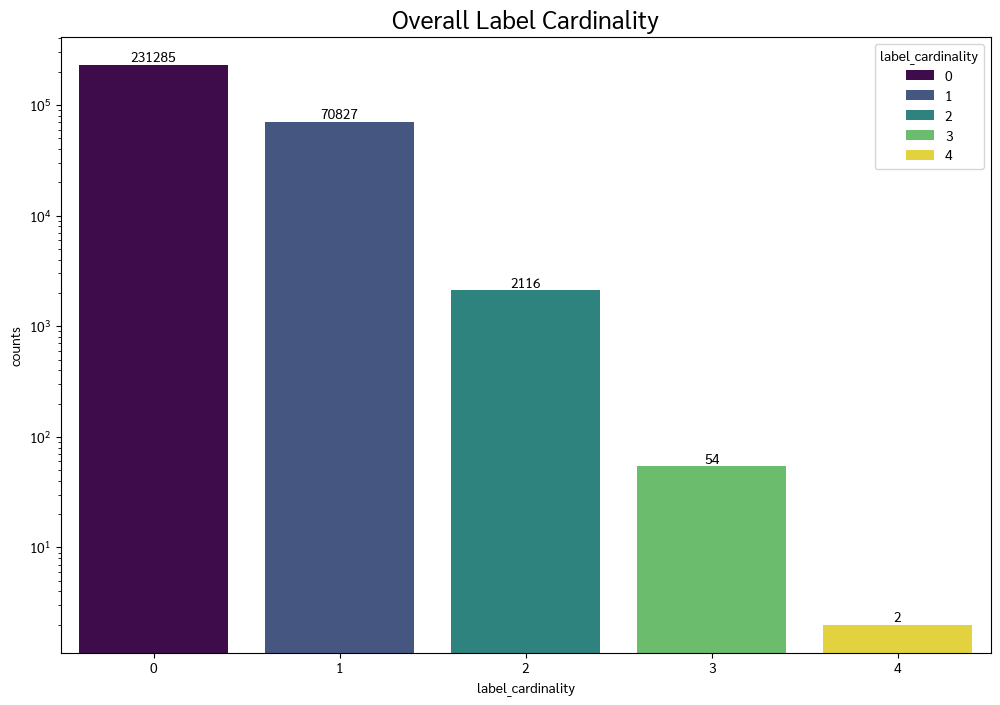

In [19]:
LabelCardinalityPlot.get_overall_plot(df_train, "Overall Label Cardinality")

## 3.4. Categorical Label Cardinality

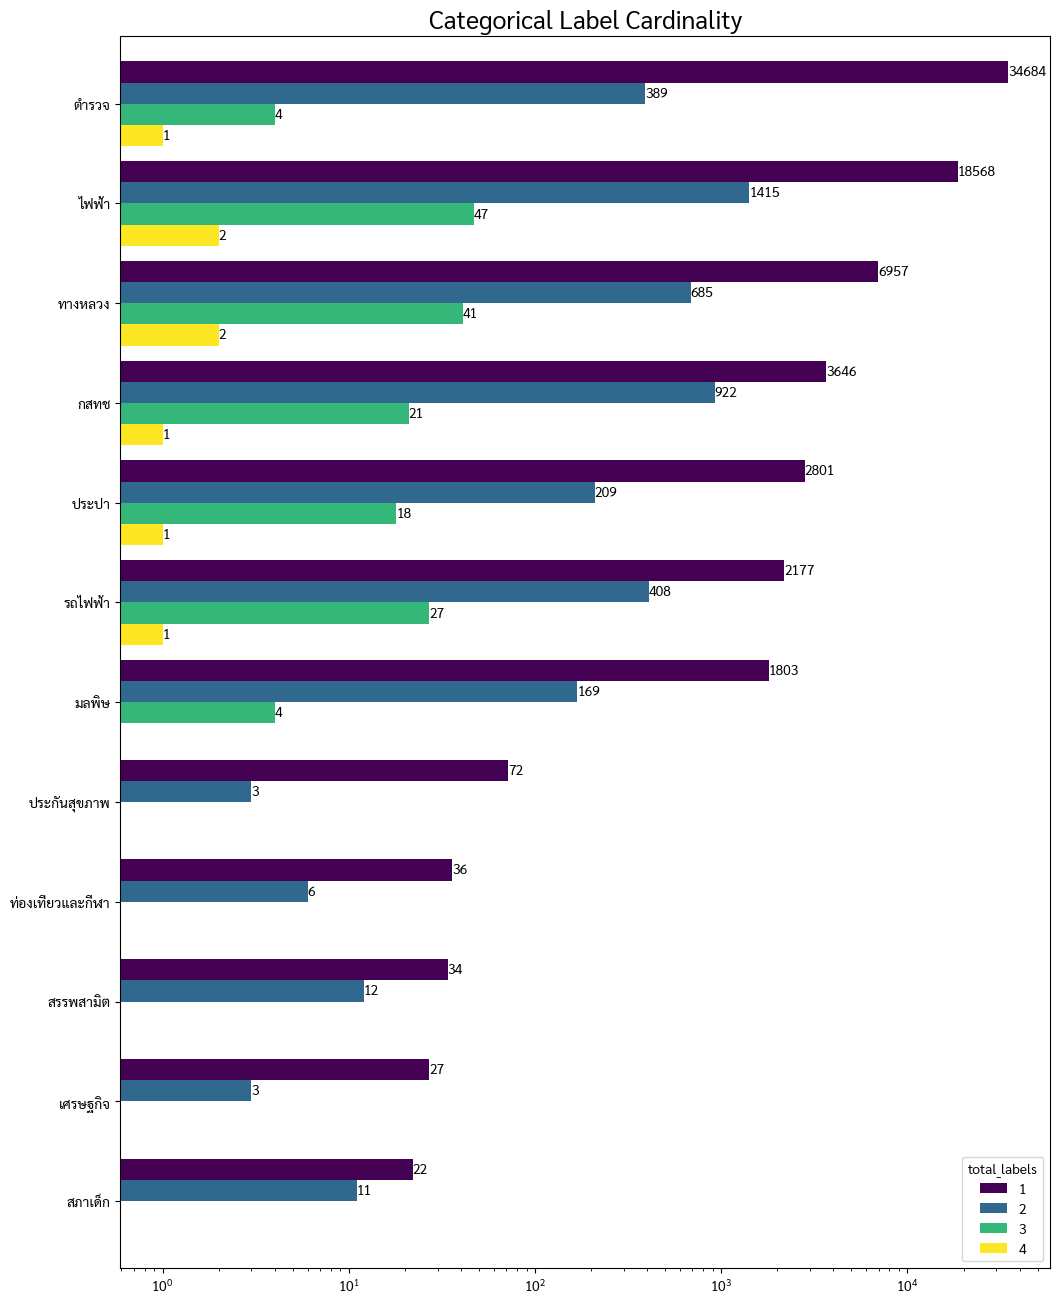

In [20]:
LabelCardinalityPlot.get_category_plot(df_train, "Categorical Label Cardinality")

# **Part 4:** Co-occurrence Matrix

## 4.1. Configuration

In [21]:
CATEGORY_MAP = {
    "สำนักงานตำรวจแห่งชาติ": "ตำรวจ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย": "รถไฟฟ้า",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร": "สภาเด็ก",
    "กรมควบคุมมลพิษ": "มลพิษ",
    "กรมสรรพสามิต": "สรรพสามิต",
    "การไฟฟ้านครหลวง": "ไฟฟ้า",
    "กรมทางหลวง": "ทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ": "ประกันสุขภาพ",
    "การประปานครหลวง": "ประปา",
    "คณะกรรมการการพัฒนาเศรษฐกิจ": "เศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา": "ท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200": "กสทช",
}

TARGET_COLS = list(CATEGORY_MAP.keys())

## 4.2. Plotting Function

In [22]:
class ClassCoOccurrenceUtility:
    @staticmethod
    def get_co_occurence_matrix(df):
        # Rename columns using map
        label_df = df[TARGET_COLS].rename(columns=CATEGORY_MAP)

        # Calculate the co-occurence matrix using dot product
        co_occurence_matrix = (label_df.T).dot(label_df)

        # Fill the diagonal with 0
        np.fill_diagonal(co_occurence_matrix.values, 0)

        # Return the co-occurence matrix
        return co_occurence_matrix

In [23]:
class ClassCoOccurrenceHeatmap:
    @staticmethod
    def get_plot(df, plot_title):
        # Calculate co-occurence matrix
        co_occurence_matrix = ClassCoOccurrenceUtility.get_co_occurence_matrix(df)

        # Create a plot figure
        plt.figure(figsize=(12, 10))
        plt.title(plot_title, fontsize=18)

        # Create a heatmap
        ax = sns.heatmap(
            data=co_occurence_matrix,
            fmt="d",
            annot=True,
            cmap="YlOrRd",
            cbar_kws={"label": "co-occurence count"},
        )

        # Display the plot
        plt.show()

## 4.3 Co-occurrence Heatmap

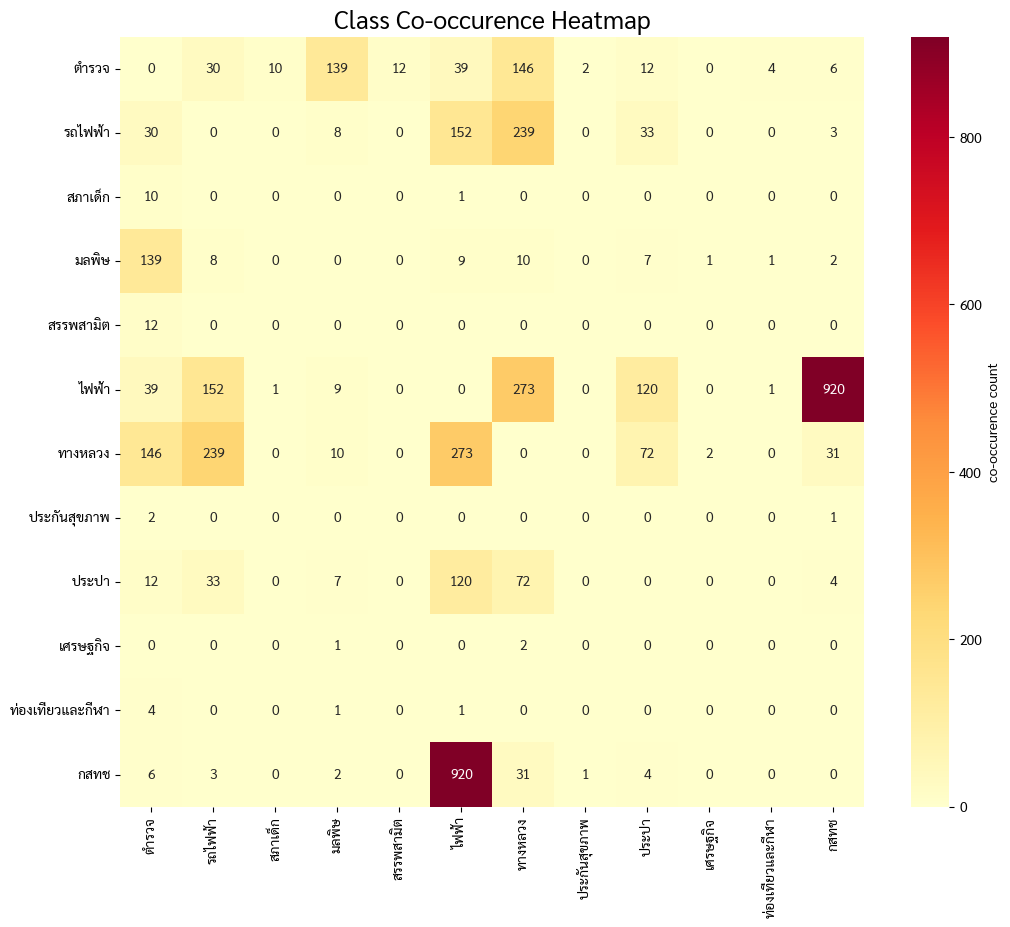

In [24]:
ClassCoOccurrenceHeatmap.get_plot(df_train, "Class Co-occurence Heatmap")

# **Part 5:** Token Length Distribution

## 5.1. Configuration

In [25]:
MODEL_NAME = "clicknext/phayathaibert"
TOKEN_LIMIT = 512

TEXT_COL = "comment"

TRAIN_COLOR = "#ff69b4"
TEST_COLOR = "#87ceeb"

TRAIN_TITLE = "Token Length on Train Dataset"
TEST_TITLE = "Token Length on Test Dataset"

TRAIN_DESC = "Calculate Token Length of Train Dataset"
TEST_DESC = "Calculate Token Length of Test Dataset"

## 5.2. Plotting Function

In [26]:
class TokenLengthUtility:
    # Load pre-trained PayaThaiBERT tokenizer
    TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)

    @staticmethod
    def get_token_length(text):
        # Handle null or empty string
        if pd.isna(text) or str(text).strip() == "":
            return 0

        # Encode text with tokenizer
        encoded_text = TokenLengthUtility.TOKENIZER.encode(str(text), truncation=False)

        # Return token length
        return len(encoded_text)

    @staticmethod
    def get_all_token_length(df, progress_desc):
        tqdm.pandas(desc=progress_desc)
        token_lengths = df[TEXT_COL].progress_apply(TokenLengthUtility.get_token_length)
        return token_lengths

    @staticmethod
    def get_token_length_stats(token_lengths):
        # Calculate minimum and maximum value
        max_length = token_lengths.max()
        mean_length = token_lengths.mean()

        # Calculate percentile
        p25 = np.percentile(token_lengths, 25)
        p50 = np.percentile(token_lengths, 50)
        p75 = np.percentile(token_lengths, 75)
        p90 = np.percentile(token_lengths, 90)
        p95 = np.percentile(token_lengths, 95)
        p99 = np.percentile(token_lengths, 99)

        # Count rows with exceeding tokens for BERT model 
        bert_exceed = (token_lengths > TOKEN_LIMIT).sum()

        # Return as a dict
        return {
            "max_length": max_length,
            "mean_length": mean_length,
            "p25": p25,
            "p50": p50,
            "p75": p75,
            "p90": p90,
            "p95": p95,
            "p99": p99,
            "bert_exceed": bert_exceed,
        }

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.26M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.4M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

In [27]:
class TokenLengthPlot:
    @staticmethod
    def get_summary(df, progress_desc, summary_title):
        # Calculate token length of the dataset.
        token_lengths = TokenLengthUtility.get_all_token_length(df, progress_desc)

        # Calculate token length stats.
        stats = TokenLengthUtility.get_token_length_stats(token_lengths)

        # Return output message
        output_message = [
            f"===== {summary_title} =====",
            f"Max length:        {stats["max_length"]} tokens",
            f"Mean length:       {stats["mean_length"]:.2f} tokens\n",
            f"25th percentile:   {int(stats["p25"])} tokens",
            f"50th percentile:   {int(stats["p50"])} tokens",
            f"75th percentile:   {int(stats["p75"])} tokens",
            f"90th percentile:   {int(stats["p90"])} tokens",
            f"95th percentile:   {int(stats["p95"])} tokens",
            f"99th percentile:   {int(stats["p99"])} tokens\n",
            f"Exceeding tokens:  {int(stats["bert_exceed"])} rows",
        ]
        return "\n".join(output_message)

    @staticmethod
    def get_plot(df, progress_desc, plot_title, plot_color):
        # Calculate token length of the dataset.
        token_lengths = TokenLengthUtility.get_all_token_length(df, progress_desc)

        # Calculate token length stats.
        stats = TokenLengthUtility.get_token_length_stats(token_lengths)

        # Create a plot figure
        plt.figure(figsize=(12, 8))
        plt.title(plot_title, fontsize=18)

        # Plot a histogram
        sns.histplot(
            data=token_lengths, bins=100, color=plot_color, alpha=0.7, kde=True
        )

        # Adjust x-axis view range to BERT token limit
        plt.xlim(0, TOKEN_LIMIT)

        # Add axis label
        plt.xlabel("Token lengths")
        plt.ylabel("Count")

        # Display the plot
        plt.show()

## 5.3. Token Length on Train Dataset

In [28]:
print(TokenLengthPlot.get_summary(df_train, TRAIN_DESC, TRAIN_TITLE))

Calculate Token Length of Train Dataset: 100%|██████████| 304284/304284 [01:44<00:00, 2910.01it/s]


===== Token Length on Train Dataset =====
Max length:        2298 tokens
Mean length:       50.43 tokens

25th percentile:   15 tokens
50th percentile:   31 tokens
75th percentile:   65 tokens
90th percentile:   101 tokens
95th percentile:   148 tokens
99th percentile:   322 tokens

Exceeding tokens:  703 rows


Calculate Token Length of Train Dataset: 100%|██████████| 304284/304284 [01:44<00:00, 2901.65it/s]


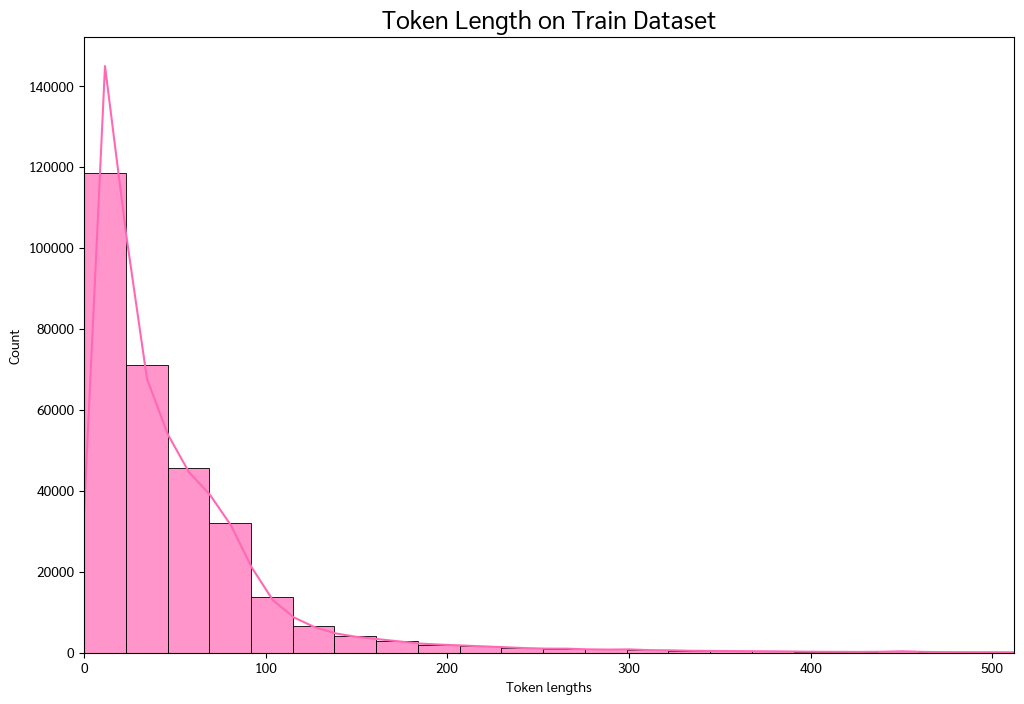

In [29]:
TokenLengthPlot.get_plot(df_train, TRAIN_DESC, TRAIN_TITLE, TRAIN_COLOR)

## 5.4. Token Length on Test Dataset

In [30]:
print(TokenLengthPlot.get_summary(df_test, TEST_DESC, TEST_TITLE))

Calculate Token Length of Test Dataset: 100%|██████████| 37406/37406 [00:14<00:00, 2666.98it/s]

===== Token Length on Test Dataset =====
Max length:        3214 tokens
Mean length:       51.48 tokens

25th percentile:   15 tokens
50th percentile:   32 tokens
75th percentile:   66 tokens
90th percentile:   105 tokens
95th percentile:   153 tokens
99th percentile:   314 tokens

Exceeding tokens:  93 rows


Calculate Token Length of Test Dataset: 100%|██████████| 37406/37406 [00:13<00:00, 2721.53it/s]


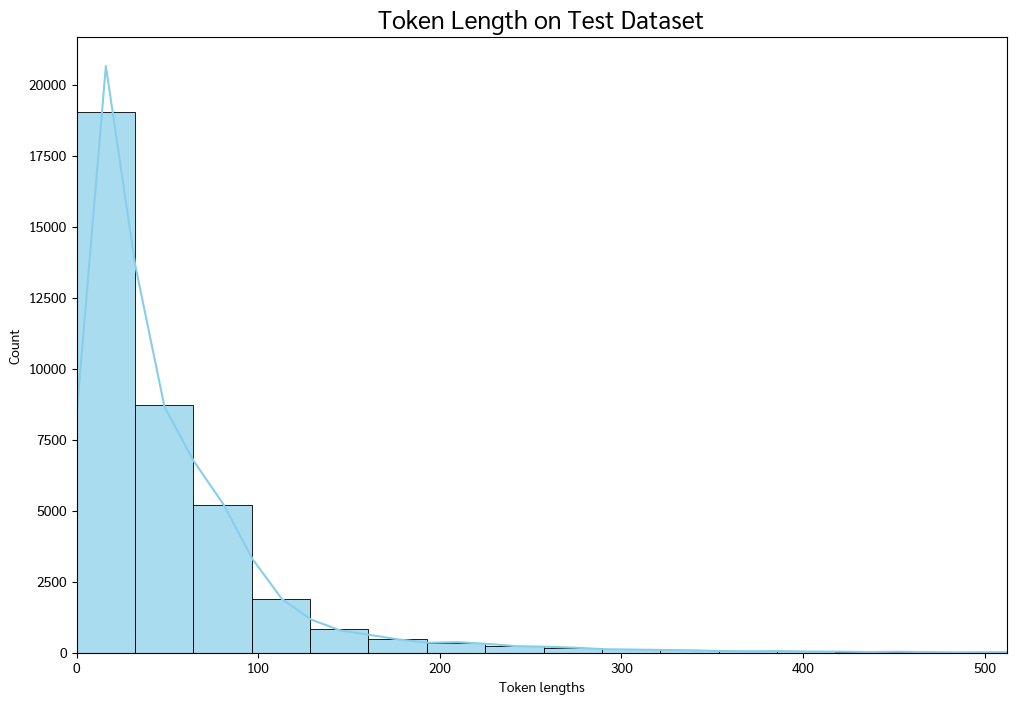

In [31]:
TokenLengthPlot.get_plot(df_test, TEST_DESC, TEST_TITLE, TEST_COLOR)

# **Part 6:** Non-Labeled Data Insight

## 6.1. Configuration

In [32]:
CATEGORY_MAP = {
    "สำนักงานตำรวจแห่งชาติ": "ตำรวจ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย": "รถไฟฟ้า",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร": "สภาเด็ก",
    "กรมควบคุมมลพิษ": "มลพิษ",
    "กรมสรรพสามิต": "สรรพสามิต",
    "การไฟฟ้านครหลวง": "ไฟฟ้า",
    "กรมทางหลวง": "ทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ": "ประกันสุขภาพ",
    "การประปานครหลวง": "ประปา",
    "คณะกรรมการการพัฒนาเศรษฐกิจ": "เศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา": "ท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200": "กสทช",
}

TARGET_COLS = list(CATEGORY_MAP.keys())

TEXT_COL = "comment"

SEED = 67

## 6.2. Data Cleaning for TF-IDF

BERT and TF-IDF has different way to prepare dataset. In this step we will perform TF-IDF just to see an insight, so we need to perform more data cleaning.

In [33]:
THAI_STOP_WORDS = frozenset(thai_stopwords())

NUMBER_PATTERN = re.compile(r"\d+")

PUNCTUATION_PATTERN = re.compile(r'[!"\'(),./:;?#-]')

In [34]:
class TextTokenizerTFIDF:
    @staticmethod
    def thai_tokenizer(text):
        if not isinstance(text, str):
            return []

        text = TextTokenizerTFIDF.remove_number(text)
        text = TextTokenizerTFIDF.remove_punctuation(text)
        return TextTokenizerTFIDF.get_tokens(text)

    @staticmethod
    def remove_number(text):
        return NUMBER_PATTERN.sub("", text)

    @staticmethod
    def remove_punctuation(text):
        return PUNCTUATION_PATTERN.sub(" ", text)

    @staticmethod
    def get_tokens(text):
        # Use Tokenizer from PyThaiNLP
        tokens = word_tokenize(text, engine="newmm-safe", keep_whitespace=False)

        # Filter only token which is not stopwords.
        filtered_tokens = []
        for token in tokens:
            cleaned_token = token.strip()
            if cleaned_token and cleaned_token not in THAI_STOP_WORDS:
                filtered_tokens.append(cleaned_token)

        # Return tokens
        return filtered_tokens

## 6.3. TF-IDF Function and NMF Models

In [35]:
class NonLabeledUtility:
    @staticmethod
    def get_non_labeled_data(df):
        # Create filter mask for zero-label data.
        mask = df[TARGET_COLS].sum(axis=1) == 0

        # Apply filter mask and drop missing value
        df_non_labeled = df[mask].dropna()

        # Return only text column.
        return df_non_labeled[TEXT_COL]

In [36]:
class NonLabeledModel:
    @staticmethod
    def get_tfidf_matrix(df):
        # Get only text column on non-labeled rows.
        corpus = NonLabeledUtility.get_non_labeled_data(df)

        # Initialize TF-IDF vectorizer
        vectorizer = TfidfVectorizer(
            tokenizer=TextTokenizerTFIDF.thai_tokenizer,
            max_df=0.85,
            min_df=5,
            ngram_range=(1, 1),
            max_features=10000,
        )

        # Calculate TF-IDF matrix
        tfidf_matrix = vectorizer.fit_transform(corpus)

        # Return both TF-IDF matrix and the vectorizer
        return tfidf_matrix, vectorizer

    @staticmethod
    def get_latent_topics(df, n_topics=10):
        # Get TF-IDF matrix and its vectorizer
        tfidf_matrix, vectorizer = NonLabeledModel.get_tfidf_matrix(df)

        # Initialize NMF model
        nmf_model = NMF(
            n_components=n_topics,
            random_state=SEED,
            init="nndsvd",
            max_iter=1000,
            alpha_H=0.1,
            alpha_W=0.1,
            l1_ratio=1.0,
        )

        # Find lantent topics
        nmf_model.fit(tfidf_matrix)

        # Return the NMF model and the vectorizer
        return nmf_model, vectorizer

In [37]:
class NonLabeledDisplay:
    @staticmethod
    def display_non_labeled_data(df, n_samples=15):
        return pd.DataFrame(NonLabeledUtility.get_non_labeled_data(df)).sample(
            n_samples, random_state=SEED
        )

    @staticmethod
    def display_tfidf_matrix(df, n_samples=15):
        # Get TF-IDF matrix and its vectorizer
        tfidf_matrix, vectorizer = NonLabeledModel.get_tfidf_matrix(df)

        # Sample rows with custom seed
        sample_matrix = resample(
            tfidf_matrix, n_samples=n_samples, random_state=SEED, replace=False
        )

        # Convert to dense NumPy array
        tfidf_arr = sample_matrix.toarray()

        # Extract the actual Thai words from the vectorizer
        feature_names = vectorizer.get_feature_names_out()

        # Create sample DataFrame
        df_sample = pd.DataFrame(tfidf_arr, columns=feature_names)

        # Filter only column with non-zeros
        df_filtered = df_sample.loc[:, (df_sample != 0).any(axis=0)]

        # Return as a DataFrame
        return df_filtered

    @staticmethod
    def display_latent_topics(df, n_topics=10, n_top_words=15):
        # Get both the trained NMF model and the vectorizer
        nmf_model, vectorizer = NonLabeledModel.get_latent_topics(df, n_topics=n_topics)

        # Extract the actual Thai words from the vectorizer
        feature_names = vectorizer.get_feature_names_out()

        # Create a dictionary to hold the top words for each topic
        topic_dict = {}

        for topic_idx, topic in enumerate(nmf_model.components_):
            # Sort the topic weights and grab the indices of the highest-scoring words
            top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]

            # Translate those numerical indices back into the actual Thai words
            top_words = [feature_names[i] for i in top_features_ind]

            # Add to the topic dictionary
            topic_dict[f"Topic {topic_idx + 1}"] = top_words

        # Display as a DataFrame
        return pd.DataFrame(topic_dict)

## 6.4. Sample Zero-label Data

In [38]:
NonLabeledDisplay.display_non_labeled_data(df_train)

,comment
190852,ซอยชุ่มชื่น 4 ถนนอโศก-ดินแดง เขตดินแดง ตลอดทั้...
126310,แจ้งปัญหาฝุ่น ซอยวัดสุขใจ15 มีดินบนใหล่ทางตลอด...
5927,bma
300747,ปัญหา: ภายในซอยดังกล่าว พบมีการติดตั้งแท่งแบริ...
155192,คนจรจัดสองคนพักใต้สะพานลอยข้ามแยกมาเกิน เดือนแล้ว
14990,ปัญหา: มีพนักงานกวาดถนนที่ตลาดซอยสว่าง 5 ทำงาน...
236646,ขายกันเต็มเลย
46631,ราวกำแพงทั้งหมดพังชำรุด
302093,ปัญหา: ตลอดทั้งซอยดังกล่าว ต้องการให้เจ้าหน้าท...
78375,บริเวณใต้ทางลงสถานี mrt บางแค หน้าทางเลี้ยวเข้...


## 6.5. TF-IDF Matrix

In [39]:
NonLabeledDisplay.display_tfidf_matrix(df_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,bma,citydata,mrt,กระจาย,กวาด,การขับขี่,การจราจร,การลอก,กำแพง,กิจ,...,โดยเร็ว,โมง,โรงพยาบาล,ใกล้เคียง,ใส่,ให้น้ำ,ได้รับความเดือดร้อน,ไม่ต้องการ,ไล่,ไหล่ทาง
0,0.0,0.123494,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.166409,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.204774,0.000000,0.000000
1,0.0,0.000000,0.000000,0.177574,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.156079,0.193364
2,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.0,0.000000,0.000000,0.000000,0.000000,0.227173,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.0,0.000000,0.000000,0.000000,0.148161,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.241027,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.518622,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.200162,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.0,0.000000,0.203347,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.213312,...,0.000000,0.189308,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 6.6. Latent Topics

In [40]:
NonLabeledDisplay.display_latent_topics(df_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,ทางเท้า,ทางเท้า,ฝา,ขยะ,ไฟ,หลุม,รถ,ป้าย,น้ำท่วม,น้ำท่วม
1,ซอย,จอด,ชำรุด,ฝา,ดับ,ถนน,จอด,รถ,น้ำ,ซอย
2,ถนน,รถ,ท่อ,ท่อ,ขยะ,บ่อ,ไฟ,กองโจร,ขัง,ป้าย
3,จอด,รถจักรยานยนต์,หลุม,ทิ้ง,ป้าย,รถ,ฝา,ฟุตบาท,ระดับ,ความสูง
4,รถ,ขับขี่,ท่อระบายน้ำ,ชำรุด,ส่องสว่าง,อุบัติเหตุ,ดับ,ป้ายโฆษณา,ความสูง,ขัง
5,บริเวณ,ขายของ,แตก,รถ,ชำรุด,ลึก,ท่อ,กีดขวาง,ทางเท้า,รถจักรยานยนต์
6,ขยะ,รถยนต์,ทางเท้า,เหม็น,มืด,ขัง,ฟุตบาท,วาง,ข้อเท้า,ระดับ
7,เขต,ขี่,ถนน,ท่อระบายน้ำ,เสา,ขยะ,ซอย,จอด,ระบาย,จอด
8,ชำรุด,ฟุตบาท,อันตราย,แตก,หลุม,น้ำท่วม,ส่องสว่าง,ทางเดิน,เดิน,ข้อเท้า
9,ปัญหา,กีดขวาง,พัง,กอง,ติด,พัง,มืด,ต้นไม้,ชั่วโมง,แยก


# **Part 7:** Labeled Data Insight

## 7.1. Configuration

In [41]:
CATEGORY_MAP = {
    "สำนักงานตำรวจแห่งชาติ": "ตำรวจ",
    "การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย": "รถไฟฟ้า",
    "สภาเด็กและเยาวชนกรุงเทพมหานคร": "สภาเด็ก",
    "กรมควบคุมมลพิษ": "มลพิษ",
    "กรมสรรพสามิต": "สรรพสามิต",
    "การไฟฟ้านครหลวง": "ไฟฟ้า",
    "กรมทางหลวง": "ทางหลวง",
    "สำนักงานประกันสุขภาพแห่งชาติ": "ประกันสุขภาพ",
    "การประปานครหลวง": "ประปา",
    "คณะกรรมการการพัฒนาเศรษฐกิจ": "เศรษฐกิจ",
    "กระทรวงการท่องเที่ยวและกีฬา": "ท่องเที่ยวและกีฬา",
    "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200": "กสทช",
}

TARGET_COLS = list(CATEGORY_MAP.keys())
SHORT_TARGET_COLS = list(CATEGORY_MAP.values())

ORGANIZATION_COL = "organization"
TEXT_COL = "comment"

SEED = 67

## 7.2. c-TF-IDF Function

In [42]:
class LabeledUtility:
    @staticmethod
    def get_category_grouped_str(df, target_col):
        # Select row labeled with the current target
        df_category = df[df[target_col] == 1]

        # Select only text column and convert them as a list
        category_texts = df_category[TEXT_COL].astype(str).tolist()

        # Join all text into one large string
        return " ".join(category_texts)

    @staticmethod
    def get_all_grouped_str(df):
        # Initialize list of dict to later convert to DataFrame
        categories_docs = []

        # Iterate each column, and group all text in column
        for target_col, short_target_col in CATEGORY_MAP.items():
            # Group all text in the current column.
            docs = LabeledUtility.get_category_grouped_str(df, target_col)

            # Append a dict of current column to a list
            categories_docs.append({ORGANIZATION_COL: short_target_col, TEXT_COL: docs})

        # Return as a DataFrame
        return pd.DataFrame(categories_docs)

In [43]:
class LabeledModel:
    @staticmethod
    def get_tfidf_matrix(df):
        # Get only text column on labeled rows.
        corpus = LabeledUtility.get_all_grouped_str(df)[TEXT_COL]

        # Initialize TF-IDF vectorizer
        vectorizer = TfidfVectorizer(
            tokenizer=TextTokenizerTFIDF.thai_tokenizer,
            max_df=0.85,
            min_df=1,
            ngram_range=(1, 1),
            max_features=10000,
        )

        # Calculate TF-IDF matrix
        tfidf_matrix = vectorizer.fit_transform(corpus)

        # Return both TF-IDF matrix and the vectorizer
        return tfidf_matrix, vectorizer

    @staticmethod
    def get_category_top_n_words(tfidf_matrix, vectorizer, target_idx, n_top_words=15):
        # Get scores of the current category
        category_scores = tfidf_matrix[target_idx].toarray().flatten()

        # Get all Thai words
        feature_names = vectorizer.get_feature_names_out()

        # Get all indices of top n words
        top_indices = np.argsort(category_scores)[: -n_top_words - 1 : -1]

        # Convert indices into Thai words
        top_words = [feature_names[i] for i in top_indices]

        return top_words

    @staticmethod
    def get_all_top_n_words(df, n_top_words=15):
        # Get TF-IDF matrix
        tfidf_matrix, vectorizer = LabeledModel.get_tfidf_matrix(df)

        # Create a dict to convert to DataFrame later
        category_tier_list = {}

        # Add top n words of each category
        for category_idx, category_name in enumerate(SHORT_TARGET_COLS):
            category_tier_list[category_name] = LabeledModel.get_category_top_n_words(
                tfidf_matrix, vectorizer, category_idx, n_top_words
            )

        # Return as a DataFrame
        return pd.DataFrame(category_tier_list)

In [44]:
class LabeledDisplay:
    @staticmethod
    def display_tfidf_matrix(df):
        # Get TF-IDF matrix and its vectorizer
        tfidf_matrix, vectorizer = LabeledModel.get_tfidf_matrix(df)

        # Convert to dense NumPy array
        tfidf_arr = tfidf_matrix.toarray()

        # Extract the actual Thai words from the vectorizer
        feature_names = vectorizer.get_feature_names_out()

        # Return as a DataFrame
        return pd.DataFrame(tfidf_arr, columns=feature_names)

## 7.3. Grouping Text

In [45]:
LabeledUtility.get_all_grouped_str(df_train)

,organization,comment
0,ตำรวจ,มีการใช้เครื่องเสียงระดับเสียงดังเกินไปจนรบกวน...
1,รถไฟฟ้า,ถนนไม่ดีเวลาขับผ่านรถสะเทือนอย่างมาก ช่วยมาซ่อ...
2,สภาเด็ก,ต้องการแจ้งปัญหาเรื่องนกพิราบที่เข้ามาอยู่อาศั...
3,มลพิษ,มลพิษทางเสียงจากช่วงเทศกาล รวมทั้งเทศกาลปีใหม่...
4,สรรพสามิต,ปัญหา: พบเห็นมีการขายสุราและบุหรี่ ทั้งขายส่งแ...
5,ไฟฟ้า,แจ้งไม่มีไฟทางเดินบริเวณฝั่งตรงข้ามไปรณีสำเหร่...
6,ทางหลวง,พิกัด คือ บนสะพานข้ามแยกรามอินทรา (มุ่งหน้าไปท...
7,ประกันสุขภาพ,บ้านอยู่ซอย ลาดพร้าว47 หลังซอยมีการก่อสร้างตลอ...
8,ประปา,ปัญหา เดิม ท่อน้ำรั่ว แตก ซึม ตรง สามแยกจอมทอง...
9,เศรษฐกิจ,ผมนายอำนวย พุทธมีขอฝากเขตหลักสี่ส่งเรื่องร้องเ...


## 7.4. TF-IDX Matrix

In [46]:
LabeledDisplay.display_tfidf_matrix(df_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,a,about,action,active,addf,af,african,after,ahw,ai,...,ๆรอ,ๆลงๆ,ๆลๆ,ๆๆ,ๆๆๆ,็,่,้,์,์ส
0,0.000910,0.000352,0.000079,0.000000,0.000000,0.000000,0.000178,0.000621,0.000311,0.001692,...,0.000267,0.000079,0.015012,0.004820,0.003427,0.000393,0.000157,0.000393,0.000959,0.000000
1,0.001064,0.000700,0.001561,0.000780,0.006172,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.004256,0.001596,0.000000,0.000000,0.000780,0.000635,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.002629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000692,...,0.000000,0.000000,0.000000,0.009989,0.002103,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013068,0.000000,0.000000
5,0.000564,0.000000,0.000000,0.000075,0.000000,0.000496,0.000000,0.000000,0.000000,0.000135,...,0.000000,0.000075,0.000000,0.002103,0.000564,0.000150,0.000075,0.000000,0.000306,0.000075
6,0.000000,0.000000,0.000383,0.001150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000344,...,0.000868,0.000767,0.000000,0.006012,0.003921,0.000383,0.000383,0.000000,0.000312,0.000383
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.001169,0.000390,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.021710,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 7.5. Keywords

In [47]:
LabeledModel.get_all_top_n_words(df_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,ตำรวจ,รถไฟฟ้า,สภาเด็ก,มลพิษ,สรรพสามิต,ไฟฟ้า,ทางหลวง,ประกันสุขภาพ,ประปา,เศรษฐกิจ,ท่องเที่ยวและกีฬา,กสทช
0,กีดขวาง,รถไฟฟ้า,เข้าเรียน,เผา,ร้าน,ดวง,สะพาน,ส่งตัว,ท่อ,กระทรวง,พลุ,สาย
1,รถติด,ก่อสร้าง,ขอทาน,ขยะ,ขาย,ส่องสว่าง,ทางเท้า,คนไข้,ประปา,porn,the,สายไฟ
2,เลน,สถานี,เยาวชน,ควัน,สุรา,ไฟฟ้า,ชำรุด,โรงพยาบาล,วาง,เว็บ,and,ห้อย
3,ห้าม,สาย,สอบถาม,กลิ่น,ใบอนุญาต,เสา,หลุม,คลินิก,ขุด,ก่อสร้าง,for,สื่อสาร
4,คัน,รามคำแหง,ซ้ำซ้อน,เหม็น,บุหรี่,เลขที่,ข้าม,การรักษา,แตก,ดิจิตอล,วิจิตร,ลงมา
5,จราจร,เลน,อบรม,ฝุ่น,จำหน่าย,ชำรุด,เส้น,คลีนิค,น้ำประปา,โป๊,traffywebsite,หย่อน
6,การจราจร,เส้น,สอดส่อง,ร้าน,ดนตรี,มืด,ส่องสว่าง,ปฐมภูมิ,หลุม,hub,are,ย้อย
7,พื้นที่,ข้าม,ไม่เป็นการ,ส่งกลิ่น,เบียร์,จำนวน,รามอินทรา,ทอง,การประปา,งานก่อสร้าง,ทท,เสา
8,ร้าน,ทางเท้า,เวที,ก่อสร้าง,เหล้า,ต้น,อุบัติเหตุ,บัตร,ไหล,แบน,เจ้าพระยา,ตก
9,สน,หลุม,หมู่บ้าน,คอนโด,ร้านค้า,หน้าบ้าน,เลน,รักษา,ซ่อม,เศรษฐกิจ,that,ทางเท้า


# **Part 8:** Abnormal Data

## 8.1. Configuration

In [48]:
TEXT_COL = "comment"
SEED = 67

## 8.2. Listing Function

In [49]:
class SampleComment:
    @staticmethod
    def display_category_comments(df, target_cols, n_sample=20):
        # Get list of comments which belongs to the category
        comments = SampleComment.get_category_comments(df, target_cols, n_sample)

        # Print comments to the screen
        print(f"{"=" * 100}\n{'\n'.join(target_cols)}\n{"=" * 100}\n")
        for idx, comment in enumerate(comments):
            print(f"{idx + 1}.) {comment}\n")
        print(f"{"=" * 100}")

    @staticmethod
    def get_category_comments(df, target_cols, n_sample=20):
        # Filter rows with all target category equals to 1
        mask = (df[target_cols] == 1).all(axis=1)
        df_category = df[mask][TEXT_COL]

        # Find actual number of samples to filter
        n_sample = min(n_sample, df_category.shape[0])

        # Return as a list of data
        return df_category.sample(n_sample, random_state=SEED).tolist()

## 8.3. Display Comments

In [50]:
TARGET_COLS = ["คณะกรรมการการพัฒนาเศรษฐกิจ"]
SampleComment.display_category_comments(df_train, TARGET_COLS)

คณะกรรมการการพัฒนาเศรษฐกิจ

1.) ผมนายอำนวย พุทธมีขอฝากเขตหลักสี่ส่งเรื่องร้องเรียนของผมถึงกระทรวงดิจิตอลเพื่อเศรษฐกิจและสังคมให้แบนแอปตั้งกระทู้dek dในประเทศไทยเพราะว่ามีการใช้คำหยาบคายและการบูลลี่มากมายในกระทู้นี้ไม่เหมาะสำหรับให้เด็กและเยาวชนเล่นแอปกระทู้dek dครับ

2.) ไซต์งานก่อสร้างของโครงการก่อสร้างอาคารสำนักงานส่งเสริมเศรษฐกิจดิจิทัลส่วนกลางและสิ่งปลูกสร้างประกอบ (อาคาร a)ทำงานนอกเหนือวันเวลาที่กำหนด (วันอาทิตย์) -เขตต้องเข้ามาควบคุมและลงโทษหน่วยงานที่เกี่ยวข้องทันที

3.) ผู้รับเหมาจีน ทำงานก่อสร้างไม่สนใจสิ่งแวดล้อม ร้องเรียนไปที่เขตดินแดงหลายครั้งไม่มีเจ้าหน้าที่มาตรวจสอบ mrt ห้วยขวาง ประตู 3 ปัญหาธุรกิจของชาวต่างชาติ

4.) กระทรวงส่งเสริมเศรษฐกิจดิจิตอลที่ก่อสร้างในซอยลาดพร้าว 12 แยกสองส่งเสียงดังดังดังเกินข้อกำหนดสร้างความรบกวนให้ผู้อยู่อาศัยรอบด้านมากอยากให้เขตและกรุงเทพมหานครเข้ามามาช่วยดูแลไม่ให้เกิดการรบกวนประชาชนและการก่อสร้างของอาคารราชการควรอยู่ในมาตรฐานเดียวกับการกำกับใช้มาตรฐานกฎหมายการก่อสร้างอาคารทั่วไป

5.) มีอินฟลูเอนเซอร์ไทยไปนอนแผ่บนพื้นรถไฟฟ้าของประเทศญี่ปุ่นเพ

In [51]:
TARGET_COLS = ["กระทรวงการท่องเที่ยวและกีฬา"]
SampleComment.display_category_comments(df_train, TARGET_COLS)

กระทรวงการท่องเที่ยวและกีฬา

1.) ฟุตบาทด้านข้างกระทรวงคมนาคม ฝาปิดท่อปิดไม่สนิทแล้วเอาอะไรมาปิดชั่วคราวก็ไม่รู้ครับ ดูแล้วอันตรายมาก กลัวว่าขาจะหลุดลงไปในท่อ

2.) มีรถนำเที่ยว(ไม่ทราบว่าถูกกฎหมายหรือไม่) ติดป้ายเชิญชวนนักท่องเที่ยวให้ไปเที่ยวกับตน โดยตัวป้ายนั้นผูกติดกับเสาสาธารณะทำให้คนเดินผ่านสัญจรลำบาก และคนขับยังมีกรวยจองที่จอด และยึดที่จอดรถสาธารณะเป็นของตัวเอง ทำให้ประชาชนคนอื่นไม่สามารถใช้ที่จอดรถข้างถนนได้เลย พบที่ หน้าตึก บ้าน ณ วรางค์, หน้าร้านรวด chao9 massage, และปากทางเข้าโรงแรม urbana langsuan ควรขับไล่คนกลุ่มนี้ออกไป เพราะยึดพื้นที่สาธารณะมาเป็นของตน ถนนเป็รที่ของทุกคนไม่ใช่ใครจะมาจับจองได้ และทางเดินเท้าไม่ควรมีป้ายของคนกลุ่มนี้มาขวางทางเดิน

3.) by traffy staff report for test # traffywebsite # english

4.) งาน atm จัดงานร่วมกับ กทม ใช่มั้ยคะ จัดการได้แย่มากค่ะ

5.) ปัญหา: บริเวณสะพานพระพุทธยอดฟ้า งานวิจิตรเจ้าพระยา พบการจุดพลุเสียงดังจากการจัดงานของ กระทรวงท่องเที่ยวและกีฬา เมื่อเวลา 20:45 น.จนถึง 20:50 น.ทำให้ประชาชนที่อาศัยอยู่บริเวณโดยรอบและรับผลกระทบต่อเนื่อง และไ

In [52]:
TARGET_COLS = ["การไฟฟ้านครหลวง", "สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200"]
SampleComment.display_category_comments(df_train, TARGET_COLS)

การไฟฟ้านครหลวง
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200

1.) ทางเดินพังไม่เรียบเสมอกันเดินสะดุดล้ม

2.) สายไฟห้อยตกลงมาจากเสาอันตรายคนเดินชนอาจเกิดอันตราย

3.) สายไฟห้อยลงมาไม่เป็นระเบียบเรียบร้อย

4.) สายไฟจะโดนหัวคนเดินกับคนใช้มอไซคิ์อยู่แล้ว รบกวนมาแก้ไขให้ด้วย

5.) มีการเอาเสาไฟออกแล้วมีตอคอนกรีตคาอยู่ กีดขวางการจราจร

6.) สายไฟ/สายสื่อสาร ขาดชำรุดหน้าปั้ม ปตท.ซอยบรม 97

7.) เมื่อปีที่แล้วมีการตัดสายไฟลงตามมาตรการผู้ว่า แต่เจ้าหน้าที่ไม่ยอมเก็บสักที เคยแจ้งไปตั้งแต่ปีที่แล้วครับ

8.) รถขนคอนเทนเนอร์ ไหลลงมาชนเสาไฟล้ม สายไฟห้อยเละเทะอยู่ที่พื้น ใกล้ฟุตบาทที่คนจอดรถ และเดินผ่าน ช่วยให้ใครเข้ามาดึงกลับขึ้นไปให้สูงเหนือรถและคนเดินด้วยค่ะ เห็นมีแต่พวกอินเตอร์เนตเข้ามาโยงสายตัวเองเพิ่มแบบส่งๆ ลากอยู่กับพื้น

9.) สายสื่อสารตกลงมาที่พื้นถนน

10.) สายไฟใดไม่ทราบที่ใช้งานหรือถูกตัดหรือไม่ไม่มีเจ้าหน้าที่มาตรวจสอบลงพื้นสายหย่อยห้อยตกไม่เป็นระเบียบ

11.) สะพานข้ามไปฝั่งเทคนิคมีนบุรีสายไฟจะโดนหัวปลดแก้ไขด้วยนะครับ

12.) สายไฟ

13.) สายสื่อสารขาดและห้อยตกหน้าบ้านเป็นเวลานานแล้ว แจ้งกสทช.แต่ไม่มีกา